In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
file_path = "Top 10 Healthcare Companies in the United States.xlsx"
df = pd.read_excel(file_path, sheet_name="CVS Health Corp. (CVS)", header=None)
print(df.head(10))

                       0            1      2      3        4
0                    CVS          NaN    NaN    NaN      NaN
1              StartDate   2000. 1. 1    NaN    NaN      NaN
2                EndDate  2023. 5. 27    NaN    NaN      NaN
3                    NaN          NaN    NaN    NaN      NaN
4                   Date        Close   High    Low   Volume
5  2000. 1. 3 오후 4:00:00        18.91  20.09  18.47  2694900
6  2000. 1. 4 오후 4:00:00        18.75  19.09  18.44  2586800
7  2000. 1. 5 오후 4:00:00        19.78  19.97  18.78  2482600
8  2000. 1. 6 오후 4:00:00        18.44  19.69  18.09  3086500
9  2000. 1. 7 오후 4:00:00        18.81  18.88  17.66  2799300


In [3]:
header_index = df[df.iloc[:, 0].astype(str).str.strip().eq("Date")].index[0]

print("Header index:", header_index)

Header index: 4


In [4]:
df = df.iloc[header_index:].copy()
df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)

In [5]:
print(df.head())

4                   Date  Close   High    Low   Volume
0  2000. 1. 3 오후 4:00:00  18.91  20.09  18.47  2694900
1  2000. 1. 4 오후 4:00:00  18.75  19.09  18.44  2586800
2  2000. 1. 5 오후 4:00:00  19.78  19.97  18.78  2482600
3  2000. 1. 6 오후 4:00:00  18.44  19.69  18.09  3086500
4  2000. 1. 7 오후 4:00:00  18.81  18.88  17.66  2799300


In [6]:
df.columns = df.columns.astype(str).str.strip()
print(df.columns)

Index(['Date', 'Close', 'High', 'Low', 'Volume'], dtype='str', name=4)


In [7]:
df["Date"] = df["Date"].astype(str).str.extract(r"(\d{4}\.\s*\d{1,2}\.\s*\d{1,2})")[0]

In [8]:
print(df["Date"].head(10))

0     2000. 1. 3
1     2000. 1. 4
2     2000. 1. 5
3     2000. 1. 6
4     2000. 1. 7
5    2000. 1. 10
6    2000. 1. 11
7    2000. 1. 12
8    2000. 1. 13
9    2000. 1. 14
Name: Date, dtype: str


In [9]:
df["Date"] = pd.to_datetime(df["Date"], format="%Y. %m. %d", errors="coerce")

In [10]:
df["Date"].head()

0   2000-01-03
1   2000-01-04
2   2000-01-05
3   2000-01-06
4   2000-01-07
Name: Date, dtype: datetime64[us]

In [11]:
numeric_columns = ["Close", "High", "Low", "Volume"]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [12]:
print(df.isnull().sum())

4
Date      11
Close      0
High      11
Low       11
Volume     0
dtype: int64


In [13]:
df.dropna(subset=["Date", "Close", "High", "Low", "Volume"], inplace=True)
df.reset_index(drop=True, inplace=True)

In [14]:
df = df.sort_values(by="Date").reset_index(drop=True)

In [15]:
df.head()

4,Date,Close,High,Low,Volume
0,2000-01-03,18.91,20.09,18.47,2694900
1,2000-01-04,18.75,19.09,18.44,2586800
2,2000-01-05,19.78,19.97,18.78,2482600
3,2000-01-06,18.44,19.69,18.09,3086500
4,2000-01-07,18.81,18.88,17.66,2799300


In [16]:
df.tail()

4,Date,Close,High,Low,Volume
5883,2023-05-19,69.38,69.89,69.14,7929081
5884,2023-05-22,69.42,69.85,68.71,7392199
5885,2023-05-23,69.67,69.98,68.92,6672318
5886,2023-05-24,68.82,69.80,68.64,6519710
5887,2023-05-25,67.67,68.50,66.61,10605381


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5888 entries, 0 to 5887
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    5888 non-null   datetime64[us]
 1   Close   5888 non-null   float64       
 2   High    5888 non-null   float64       
 3   Low     5888 non-null   float64       
 4   Volume  5888 non-null   int64         
dtypes: datetime64[us](1), float64(3), int64(1)
memory usage: 230.1 KB


In [18]:
df.describe()

4,Date,Close,High,Low,Volume
count,5888,5888.000000,5888.000000,5888.000000,5.888000e+03
mean,2011-09-15 03:38:53.152174,50.799935,51.308736,50.271904,6.796123e+06
min,2000-01-03 00:00:00,11.000000,11.400000,10.920000,2.500000e+03
25%,2005-11-08 18:00:00,28.260000,28.680000,27.750000,3.317962e+06
50%,2011-09-13 12:00:00,40.865000,41.245000,40.285000,5.608830e+06
75%,2017-07-20 06:00:00,74.652500,75.340000,74.082500,8.649924e+06
max,2023-05-25 00:00:00,113.450000,113.650000,112.450000,1.851235e+08
std,NaN,28.088438,28.293456,27.882928,5.803230e+06


In [19]:
df.dtypes

4
Date      datetime64[us]
Close            float64
High             float64
Low              float64
Volume             int64
dtype: object

In [20]:
df.isnull().sum()

4
Date      0
Close     0
High      0
Low       0
Volume    0
dtype: int64

In [21]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
5883    False
5884    False
5885    False
5886    False
5887    False
Length: 5888, dtype: bool

In [22]:
df.shape

(5888, 5)

In [23]:
print("Start Date:", df["Date"].min())

Start Date: 2000-01-03 00:00:00


In [24]:
print("End Date:", df["Date"].max())

End Date: 2023-05-25 00:00:00


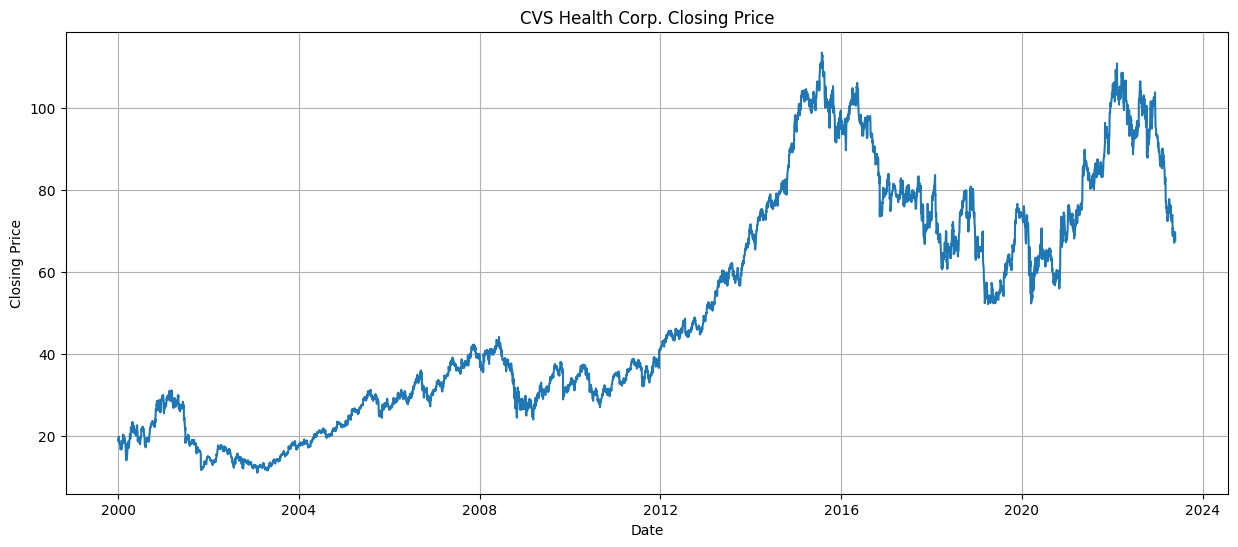

In [25]:
plt.figure(figsize=(15, 6))
plt.plot(df["Date"], df["Close"])
plt.title("CVS Health Corp. Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)
plt.show()

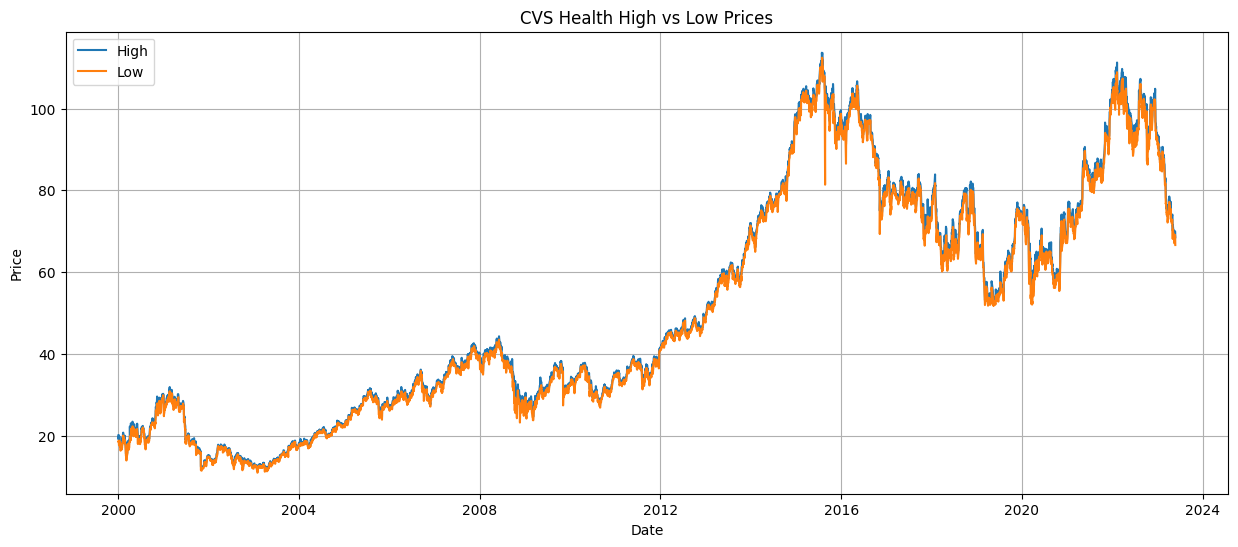

In [26]:
plt.figure(figsize=(15, 6))
plt.plot(df["Date"], df["High"], label="High")
plt.plot(df["Date"], df["Low"], label="Low")
plt.title("CVS Health High vs Low Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

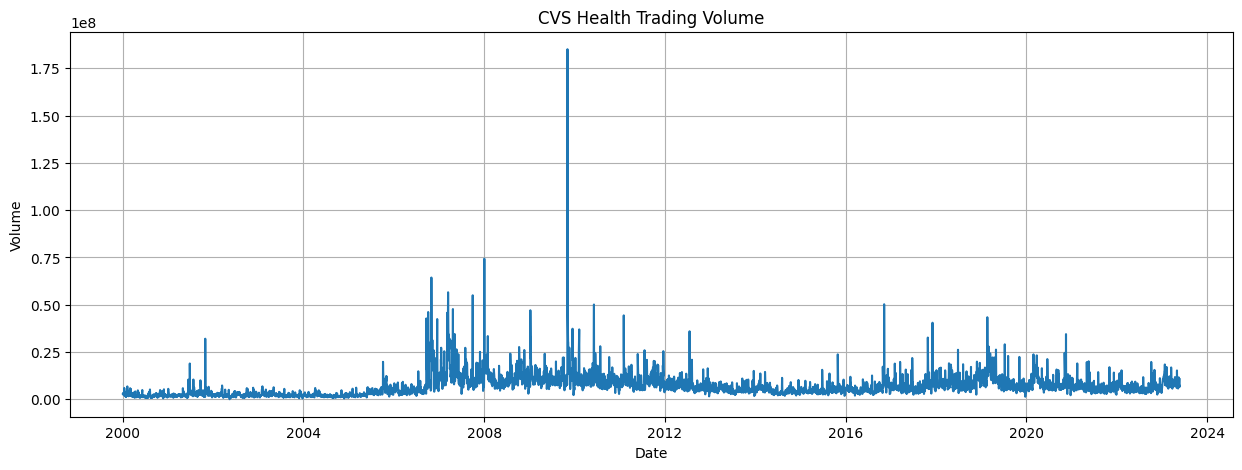

In [27]:
plt.figure(figsize=(15, 5))
plt.plot(df["Date"], df["Volume"])
plt.title("CVS Health Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)
plt.show()

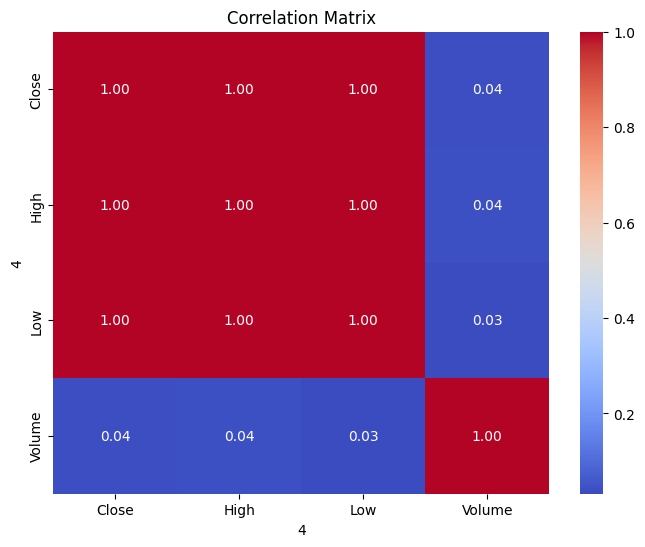

In [28]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[["Close", "High", "Low", "Volume"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
)
plt.title("Correlation Matrix")
plt.show()

In [32]:
df["MA_30"] = df["Close"].rolling(window=30).mean()
df["MA_90"] = df["Close"].rolling(window=90).mean()

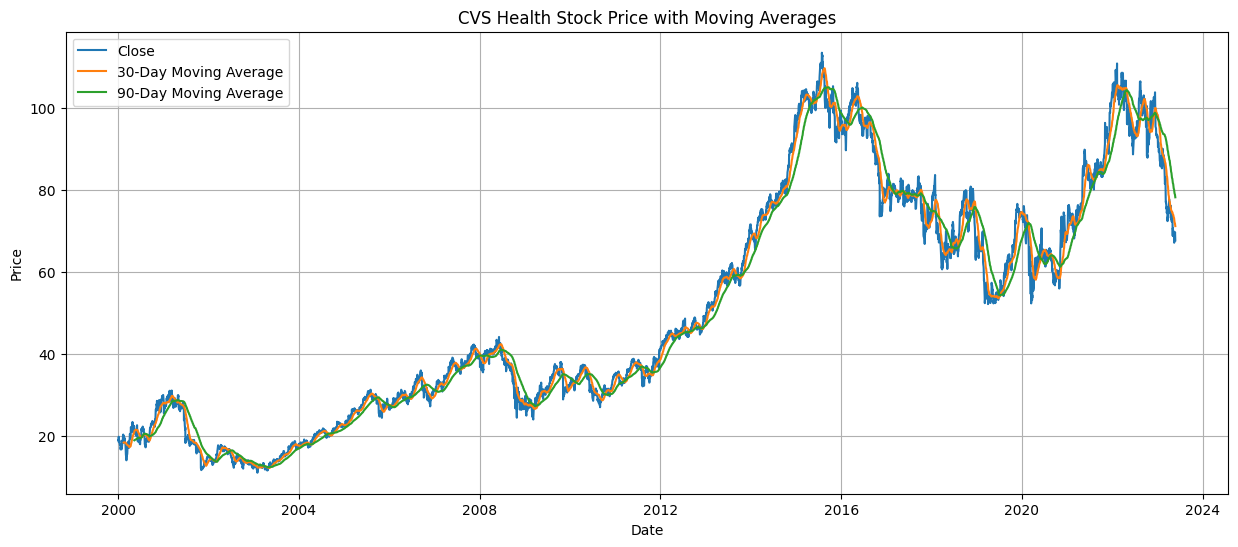

In [33]:
plt.figure(figsize=(15, 6))
plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["MA_30"], label="30-Day Moving Average")
plt.plot(df["Date"], df["MA_90"], label="90-Day Moving Average")
plt.title("CVS Health Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

In [34]:
df["Daily_Return"] = df["Close"].pct_change()

In [35]:
df[["Date", "Close", "Daily_Return"]].head(10)

4,Date,Close,Daily_Return
0,2000-01-03,18.91,NaN
1,2000-01-04,18.75,-0.008461
2,2000-01-05,19.78,0.054933
3,2000-01-06,18.44,-0.067745
4,2000-01-07,18.81,0.020065
5,2000-01-10,18.75,-0.003190
6,2000-01-11,18.84,0.004800
7,2000-01-12,18.81,-0.001592
8,2000-01-13,18.44,-0.019670
9,2000-01-14,17.81,-0.034165


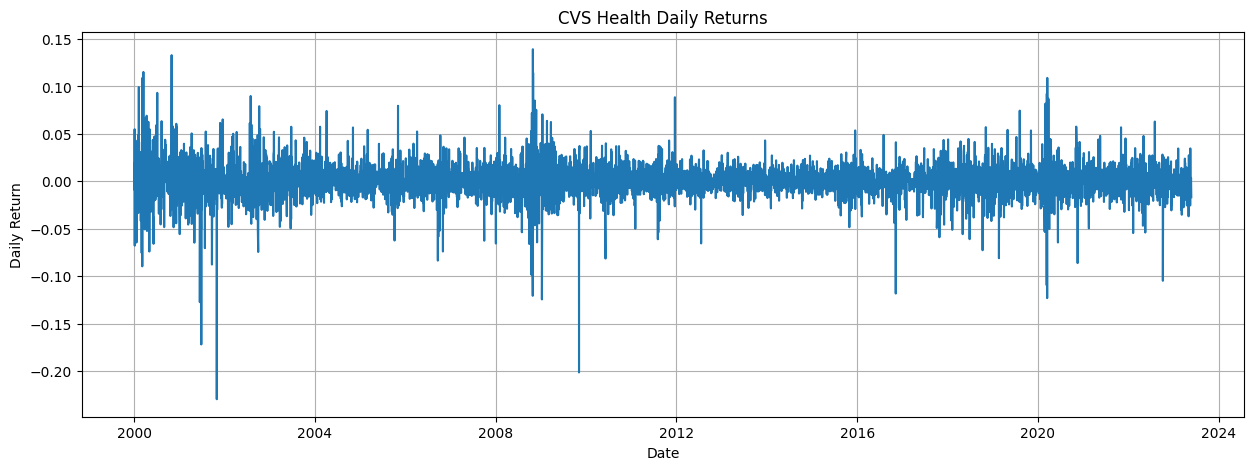

In [36]:
plt.figure(figsize=(15, 5))
plt.plot(df["Date"], df["Daily_Return"])
plt.title("CVS Health Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.grid(True)
plt.show()

In [37]:
df["Volatility_30"] = df["Daily_Return"].rolling(30).std()

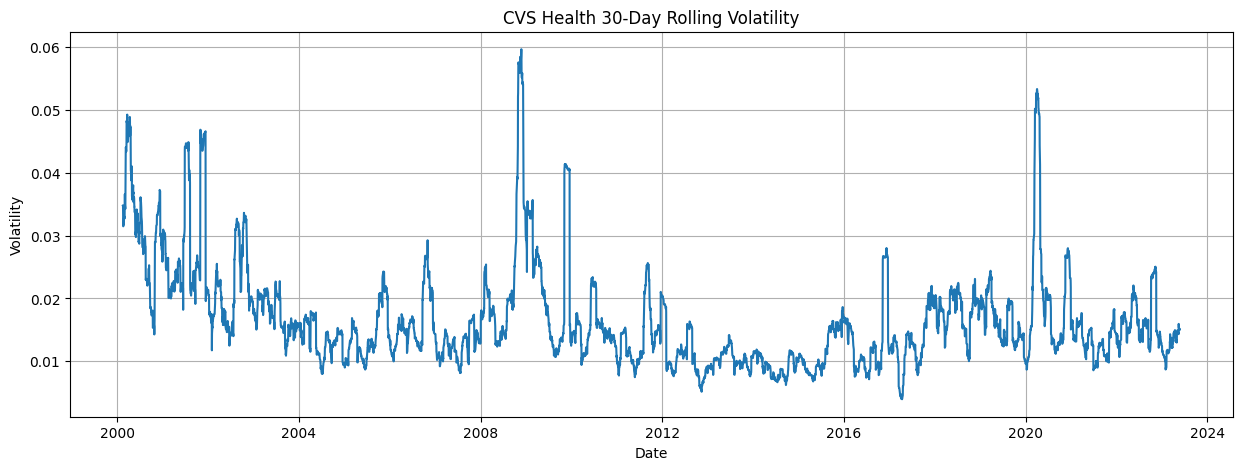

In [38]:
plt.figure(figsize=(15, 5))
plt.plot(df["Date"], df["Volatility_30"])
plt.title("CVS Health 30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

In [39]:
print(df.columns.tolist())

['Date', 'Close', 'High', 'Low', 'Volume', 'MA_30', 'MA_90', 'Daily_Return', 'Volatility_30']


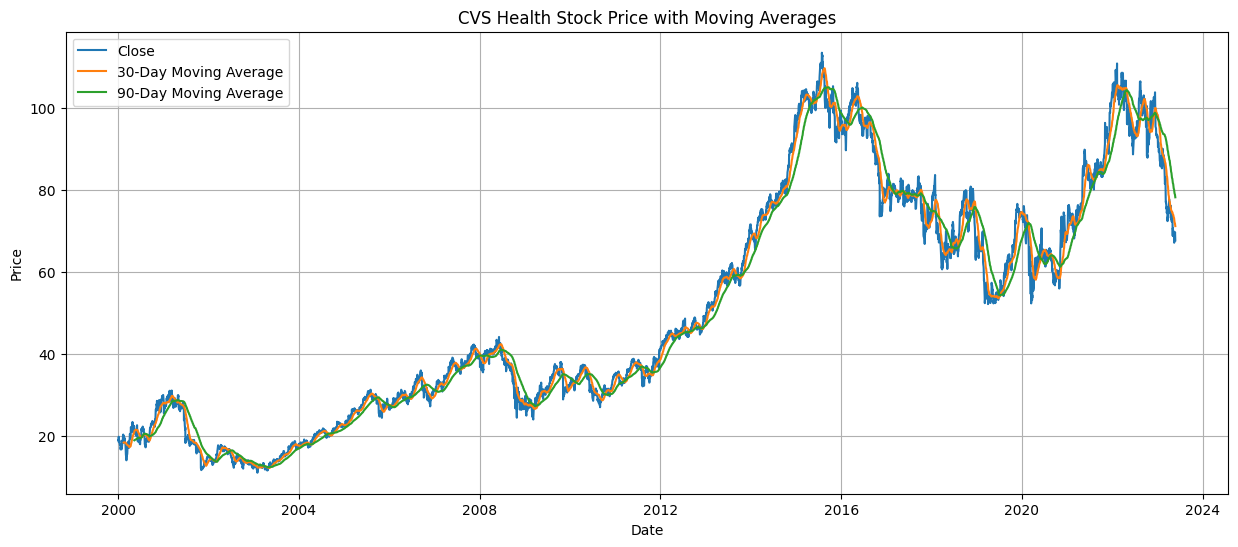

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["MA_30"], label="30-Day Moving Average")
plt.plot(df["Date"], df["MA_90"], label="90-Day Moving Average")
plt.title("CVS Health Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

In [41]:
df["Daily_Return"] = df["Close"].pct_change()

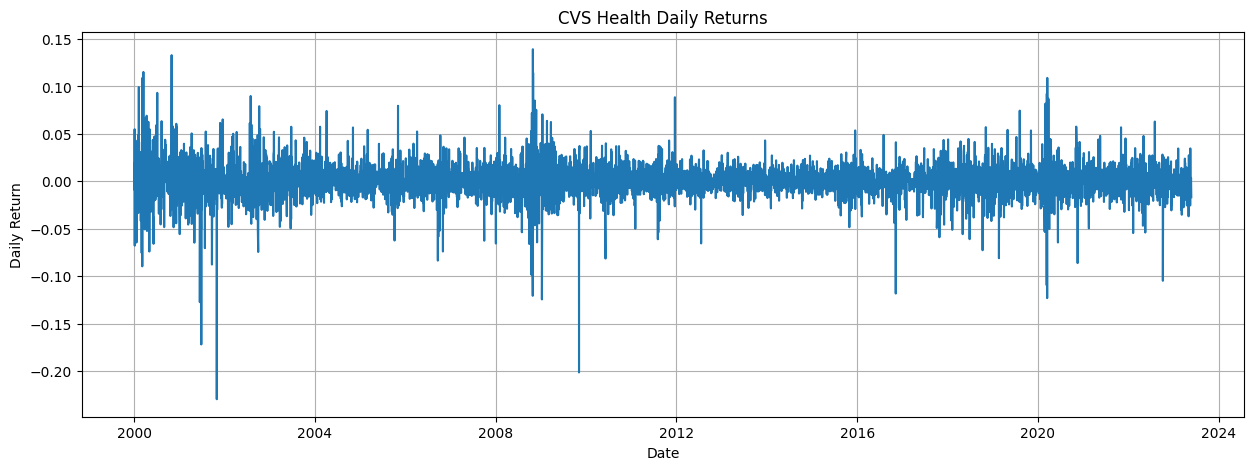

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(df["Date"], df["Daily_Return"])
plt.title("CVS Health Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.grid(True)
plt.show()

In [ ]:
df["Volatility_30"] = df["Daily_Return"].rolling(30).std()

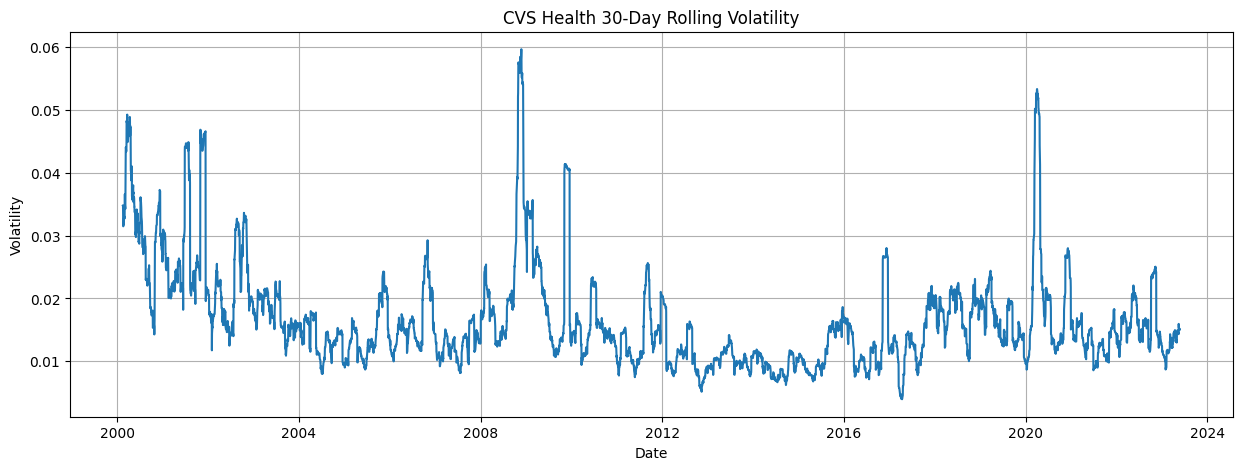

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(df["Date"], df["Volatility_30"])
plt.title("CVS Health 30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

In [45]:
data = df[["Date", "Close"]].copy()

In [46]:
data.head()

4,Date,Close
0,2000-01-03,18.91
1,2000-01-04,18.75
2,2000-01-05,19.78
3,2000-01-06,18.44
4,2000-01-07,18.81


In [47]:
data.tail()

4,Date,Close
5883,2023-05-19,69.38
5884,2023-05-22,69.42
5885,2023-05-23,69.67
5886,2023-05-24,68.82
5887,2023-05-25,67.67


In [49]:
data.shape

(5888, 2)

In [50]:
train_size = int(len(data) * 0.80)
train_data = data.iloc[:train_size].copy()
test_data = data.iloc[train_size:].copy()

In [51]:
print("Training rows:", len(train_data))
print("Testing rows:", len(test_data))

Training rows: 4710
Testing rows: 1178


In [52]:
print("Training period:")
print(train_data["Date"].min(), "to", train_data["Date"].max())

Training period:
2000-01-03 00:00:00 to 2018-09-19 00:00:00


In [53]:
print("Testing period:")
print(test_data["Date"].min(), "to", test_data["Date"].max())

Testing period:
2018-09-20 00:00:00 to 2023-05-25 00:00:00


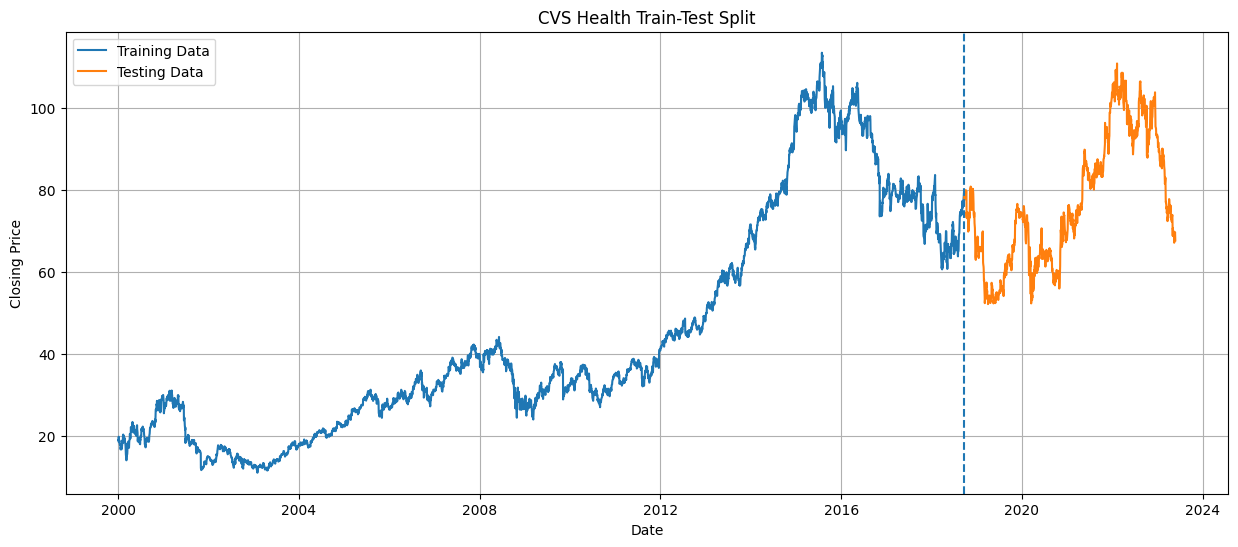

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(train_data["Date"], train_data["Close"], label="Training Data")
plt.plot(test_data["Date"], test_data["Close"], label="Testing Data")
plt.axvline(test_data["Date"].iloc[0], linestyle="--")
plt.title("CVS Health Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

In [56]:
train_scaled = scaler.fit_transform(train_data[["Close"]])
test_scaled = scaler.transform(test_data[["Close"]])
print("Train scaled shape:", train_scaled.shape)
print("Test scaled shape:", test_scaled.shape)

Train scaled shape: (4710, 1)
Test scaled shape: (1178, 1)


In [57]:
lookback = 60

In [ ]:
X_train = []
y_train = []
for i in range(lookback, len(train_scaled)):
    X_train.append(train_scaled[i - lookback : i, 0])
    y_train.append(train_scaled[i, 0])
X_train = np.array(X_train)
y_train = np.array(y_train)

In [59]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (4650, 60)
y_train shape: (4650,)


In [ ]:
combined_data = np.concatenate([train_scaled[-lookback:], test_scaled])
print("Combined shape:", combined_data.shape)

Combined shape: (1238, 1)


In [ ]:
X_test = []
y_test = []
for i in range(lookback, len(combined_data)):
    X_test.append(combined_data[i - lookback : i, 0])
    y_test.append(combined_data[i, 0])
X_test = np.array(X_test)
y_test = np.array(y_test)

In [62]:
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (1178, 60)
y_test shape: (1178,)


In [ ]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [64]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (4650, 60, 1)
X_test: (1178, 60, 1)


In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss", patience=8, restore_best_weights=True
)

In [ ]:
lstm_model = Sequential(
    [
        LSTM(
            64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])
        ),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(1),
    ]
)

In [ ]:
lstm_model.compile(optimizer="adam", loss="mse")

In [68]:
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss", patience=8, restore_best_weights=True
)

In [ ]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - loss: 0.0066 - val_loss: 7.9326e-04
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - loss: 0.0016 - val_loss: 9.2785e-04
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 0.0014 - val_loss: 0.0021
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 0.0012 - val_loss: 0.0010
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - loss: 0.0010 - val_loss: 0.0011
Epoch 6/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 14s 107ms/step - loss: 9.6672e-04 - val_loss: 0.0039
Epoch 7/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - loss: 9.7008e-04 - val_loss: 0.0019
Epoch 8/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - loss: 8.1760e-04 - val_loss: 6.0673e-04
Epoch 9/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - loss: 8.0943e-04 - val_loss: 9.5491e-04
Epoch 10/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - loss: 6.8792e-04 - val_loss: 5.7928e-04
Epoch 11/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - loss: 7.3316e-04 - val_loss:

In [ ]:
print("Epochs actually trained:", len(history_lstm.history["loss"]))
print("Best validation loss:", min(history_lstm.history["val_loss"]))

Epochs actually trained: 18
Best validation loss: 0.0005792831652797759


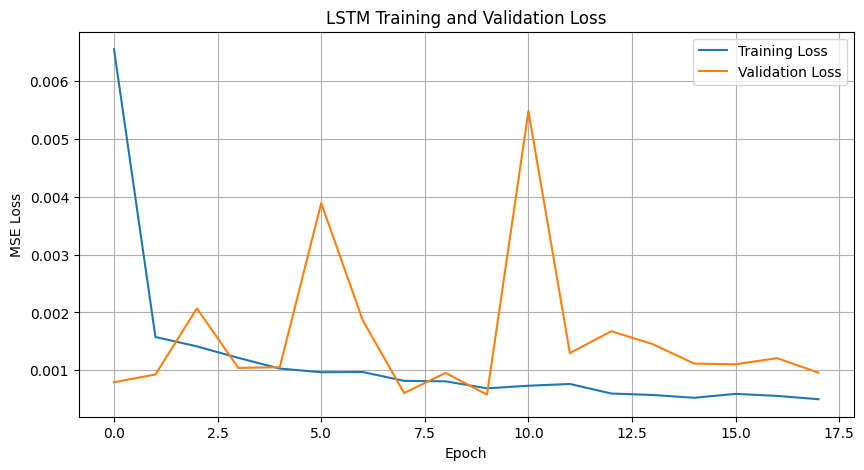

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history_lstm.history["loss"], label="Training Loss")
plt.plot(history_lstm.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

In [74]:
lstm_pred_scaled = lstm_model.predict(X_test)
print(lstm_pred_scaled.shape)

37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step
(1178, 1)


In [75]:
lstm_pred = scaler.inverse_transform(lstm_pred_scaled).flatten()
actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

In [76]:
print("Actual prices:")
print(actual[:10])

Actual prices:
[79.39 79.59 78.74 77.61 78.43 78.76 78.72 79.5  79.24 79.9 ]


In [77]:
print("\nPredicted prices:")
print(lstm_pred[:10])


Predicted prices:
[76.57753  76.91702  77.26513  77.55643  77.73554  77.86961  77.98274
 78.072945 78.18155  78.28376 ]


In [ ]:
mae = mean_absolute_error(actual, lstm_pred)

In [ ]:
mse = mean_squared_error(actual, lstm_pred)

In [80]:
rmse = np.sqrt(mse)

In [81]:
mape = np.mean(np.abs((actual - lstm_pred) / actual)) * 100

In [ ]:
r2 = r2_score(actual, lstm_pred)

In [83]:
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

MAE  : 2.2944
MSE  : 9.5013
RMSE : 3.0824
MAPE : 2.93%
R²   : 0.9614


In [ ]:
prediction_df = pd.DataFrame(
    {
        "Date": test_data["Date"].values,
        "Actual_Close": actual,
        "Predicted_Close": lstm_pred,
    }
)
prediction_df.head(10)

,Date,Actual_Close,Predicted_Close
0,2018-09-20,79.39,76.577530
1,2018-09-21,79.59,76.917023
2,2018-09-24,78.74,77.265129
3,2018-09-25,77.61,77.556427
4,2018-09-26,78.43,77.735542
5,2018-09-27,78.76,77.869614
6,2018-09-28,78.72,77.982742
7,2018-10-01,79.50,78.072945
8,2018-10-02,79.24,78.181549
9,2018-10-03,79.90,78.283760


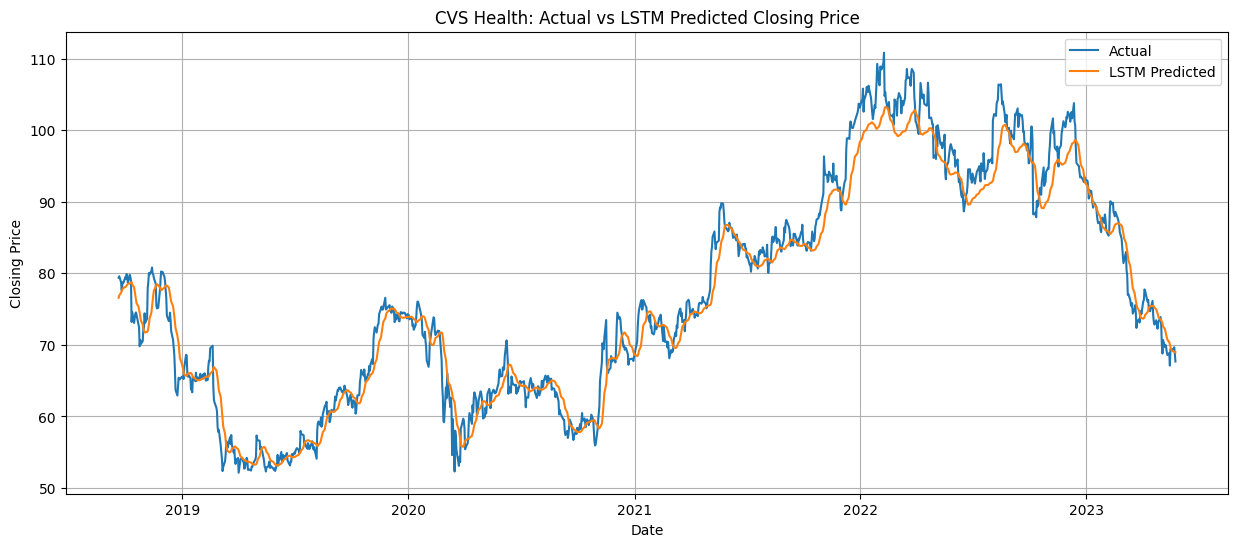

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(prediction_df["Date"], prediction_df["Actual_Close"], label="Actual")
plt.plot(
    prediction_df["Date"], prediction_df["Predicted_Close"], label="LSTM Predicted"
)
plt.title("CVS Health: Actual vs LSTM Predicted Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
prediction_df["Error"] = (
    prediction_df["Actual_Close"] - prediction_df["Predicted_Close"]
)

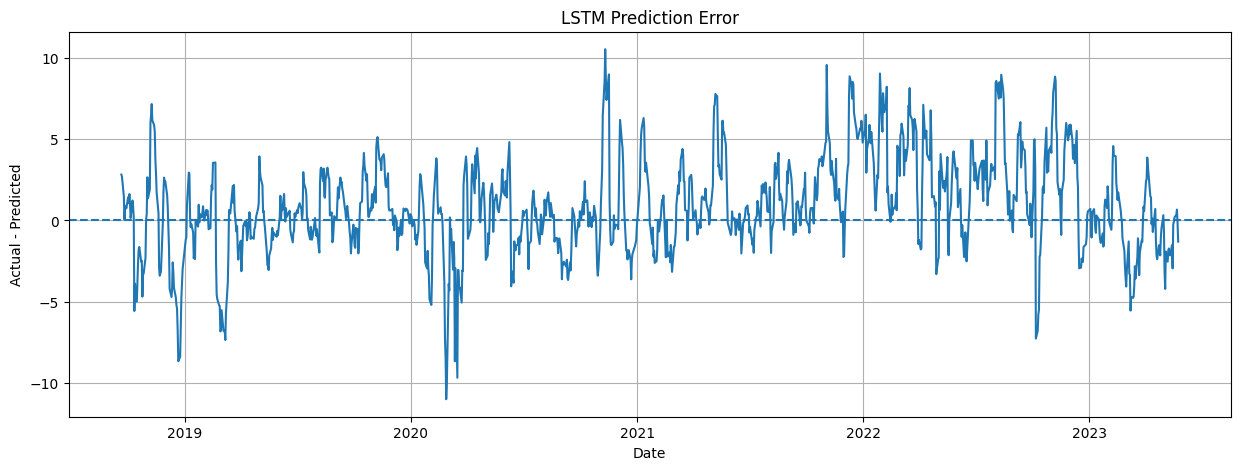

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(prediction_df["Date"], prediction_df["Error"])
plt.axhline(0, linestyle="--")
plt.title("LSTM Prediction Error")
plt.xlabel("Date")
plt.ylabel("Actual - Predicted")
plt.grid(True)
plt.show()

In [88]:
prediction_df.head(20)

,Date,Actual_Close,Predicted_Close,Error
0,2018-09-20,79.39,76.577530,2.812470
1,2018-09-21,79.59,76.917023,2.672977
2,2018-09-24,78.74,77.265129,1.474871
3,2018-09-25,77.61,77.556427,0.053573
4,2018-09-26,78.43,77.735542,0.694458
5,2018-09-27,78.76,77.869614,0.890386
6,2018-09-28,78.72,77.982742,0.737258
7,2018-10-01,79.50,78.072945,1.427055
8,2018-10-02,79.24,78.181549,1.058451
9,2018-10-03,79.90,78.283760,1.616240


In [ ]:
prediction_df["Percentage_Error"] = (
    np.abs(prediction_df["Actual_Close"] - prediction_df["Predicted_Close"])
    / prediction_df["Actual_Close"]
) * 100

In [ ]:
prediction_df[["Date", "Actual_Close", "Predicted_Close", "Percentage_Error"]].head(20)

,Date,Actual_Close,Predicted_Close,Percentage_Error
0,2018-09-20,79.39,76.577530,3.542600
1,2018-09-21,79.59,76.917023,3.358434
2,2018-09-24,78.74,77.265129,1.873090
3,2018-09-25,77.61,77.556427,0.069028
4,2018-09-26,78.43,77.735542,0.885449
5,2018-09-27,78.76,77.869614,1.130506
6,2018-09-28,78.72,77.982742,0.936557
7,2018-10-01,79.50,78.072945,1.795038
8,2018-10-02,79.24,78.181549,1.335753
9,2018-10-03,79.90,78.283760,2.022828


In [ ]:
prediction_df["Error"] = (
    prediction_df["Actual_Close"] - prediction_df["Predicted_Close"]
)
prediction_df["Absolute_Error"] = np.abs(prediction_df["Error"])

In [ ]:
print(
    prediction_df[
        ["Date", "Actual_Close", "Predicted_Close", "Error", "Absolute_Error"]
    ]
    .sort_values("Absolute_Error", ascending=False)
    .head(20)
)

           Date  Actual_Close  Predicted_Close      Error  Absolute_Error
360  2020-02-27         59.33        70.311363 -10.981363       10.981363
539  2020-11-10         70.23        59.718502  10.511498       10.511498
361  2020-02-28         59.18        69.209724 -10.029724       10.029724
372  2020-03-16         52.30        61.963940  -9.663940        9.663940
786  2021-11-03         96.34        86.796043   9.543957        9.543957
845  2022-01-28        109.27       100.249985   9.020015        9.020015
543  2020-11-16         73.47        64.504997   8.965003        8.965003
980  2022-08-12        106.39        97.441086   8.948914        8.948914
812  2021-12-10         98.86        90.012512   8.847488        8.847488
1040 2022-11-07        101.18        92.349358   8.830642        8.830642
540  2020-11-11         69.51        60.792046   8.717954        8.717954
370  2020-03-12         54.60        63.252209  -8.652209        8.652209
64   2018-12-21         63.70        7

In [ ]:
actual_direction = np.sign(np.diff(actual))
predicted_direction = np.sign(np.diff(lstm_pred))
directional_accuracy = np.mean(actual_direction == predicted_direction) * 100
print(f"Directional Accuracy: " f"{directional_accuracy:.2f}%")

Directional Accuracy: 50.81%


In [94]:
latest_60 = df["Close"].tail(60).values.reshape(-1, 1)

In [95]:
latest_60_scaled = scaler.transform(latest_60)

In [ ]:
X_next = latest_60_scaled.reshape(1, 60, 1)
print(X_next.shape)

(1, 60, 1)


In [97]:
next_day_scaled = lstm_model.predict(X_next)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


In [ ]:
next_day_price = scaler.inverse_transform(next_day_scaled)[0][0]
print(f"Predicted next-day closing price: " f"${next_day_price:.2f}")

Predicted next-day closing price: $68.90


In [99]:
last_price = df["Close"].iloc[-1]
change = next_day_price - last_price
change_percent = (change / last_price) * 100

In [100]:
print(f"Last actual closing price: ${last_price:.2f}")
print(f"Predicted next-day price: ${next_day_price:.2f}")
print(f"Expected change: ${change:.2f}")
print(f"Expected change %: {change_percent:.2f}%")

Last actual closing price: $67.67
Predicted next-day price: $68.90
Expected change: $1.23
Expected change %: 1.81%


In [ ]:
forecast = pd.DataFrame(
    {
        "Last_Actual_Close": [last_price],
        "Predicted_Next_Day_Close": [next_day_price],
        "Expected_Change": [change],
        "Expected_Change_Percent": [change_percent],
    }
)

In [103]:
forecast

,Last_Actual_Close,Predicted_Next_Day_Close,Expected_Change,Expected_Change_Percent
0,67.67,68.897621,1.227621,1.814129
